In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import itertools
import json
import os

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import sklearn
import sklearn.cluster
import torch
import tqdm
import umap

import celltrip


mpl.rcParams['pdf.fonttype'] = 42


2026-07-24 18:10:44.449412: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load Data and Policy

In [3]:
# Read data
adata, = celltrip.utility.processing.read_adatas('s3://nkalafut-celltrip/DrugSeries/expression.h5ad', backed=True)

# Model location and name
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251013', 800  # 32 dim - best for interp stages (USE)
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110', 800  # 32 dim - sample normalized
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110-cont', 1600  # 32 dim - sample normalized
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110-log', 800  # 32 dim - sample and log normalized
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251111-logclip', 800  # 32 dim - sample and log normalized, with clipping
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251113-pip', 800  # 32 dim - pipart fix
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-260610', 800,  # Reproduction run
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-260610-1', 800,  # Reproduction run
prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-260614', 800  # Reproduction run USE
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-260622', 800,  # Reproduction run
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-DMSO-3hr-260621', 800  # DMSO(-48hr) -> Tram(3hr)
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-DMSO-6hr-260621', 800  # DMSO(-48hr) -> Tram(6hr)
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-DMSO-12hr-260619', 800  # DMSO(-48hr) -> Tram(12hr)
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-DMSO-24hr-260621', 800  # DMSO(-48hr) -> Tram(24hr)
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/Drugseries-DMSO-48hr-260619', 800  # DMSO(-48hr) -> Tram(48hr)

# Load preprocessing
preprocessing = celltrip.utility.processing.Preprocessing().load(f'{prefix}.pre')
with celltrip.utility.general.open_s3_or_local(f'{prefix}.mask', 'rb') as f:
    mask = np.loadtxt(f).astype(bool)
adata.obs['Training'] = mask

# Create sample env (kind of a dumb workaround, TODO)
m1, = preprocessing.transform([adata[:2].X])
env = celltrip.environment.EnvironmentBase(
    torch.tensor(m1), compute_rewards=False, dim=32).eval().to('cuda')

# Load policy
policy = celltrip.policy.create_agent_from_env(
    env, forward_batch_size=1_000, vision_size=1_000).eval().to('cuda')
policy.load_checkpoint(f'{prefix}-{training_step:04}.weights');

# Run Untreated and Knockdown

In [4]:
# Parameters
print(adata.obs['treatment'].unique().to_numpy())
series = ['Untreated', 'DMSO', 'Tram']
timesteps = ['3hr', '6hr', '12hr', '24hr', '48hr']

# User-defined
common_mask = np.ones(adata.shape[0], dtype=bool)
# common_mask = adata.obs['cell_line'] == 'CENTRAL_NERVOUS_SYSTEM'
untreated_target = 'DMSO_48hr'  # Untreated_48hr
knocked_target = 'Tram_48hr'
train_mask_col = 'train' if knocked_target != 'Tram_24hr' else 'train_dmso_24hr'
gene_names = ['MAP2K1', 'MAP2K2']  # 'BRAF', 'NRAS', 'KRAS', 'RAF1', 'NF1'

# Functions
# preprocess_common = lambda x: preprocessing.inverse_transform(preprocessing.transform([x]))[0]
# normalize_counts = lambda x: 10_000 * x / x.sum(keepdims=True, axis=-1)
# preprocess_normalize = lambda x: normalize_counts(preprocess_common(x))
preprocess_raw_to_norm = lambda x: preprocessing.transform([x], steps=['filter', 'sample_count', 'pre_log', 'standardize'])[0]
preprocess_norm_to_raw = lambda x: preprocessing.inverse_transform([x], steps=['standardize', 'pre_log'])[0]  # No `sample_count`
preprocess_norm_to_pre = lambda x: preprocessing.transform([x], steps=['pca'])[0]
preprocess_pre_to_norm = lambda x: preprocessing.inverse_transform([x], steps=['pca'])[0]
preprocess_norm_to_norm = lambda x: preprocess_pre_to_norm(preprocess_norm_to_pre(x))

['DMSO_48hr' 'Tram_24hr' 'DMSO_12hr' 'Tram_3hr' 'Tram_6hr' 'Tram_12hr'
 'Tram_48hr' 'Untreated_48hr' 'DMSO_3hr' 'DMSO_24hr' 'DMSO_6hr']


## Visualize Distributions

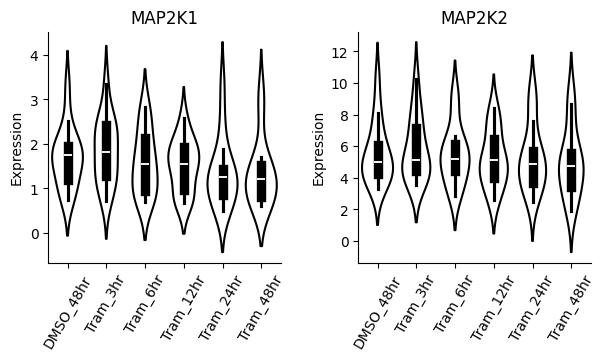

In [5]:
# Get time series data
target_order = [untreated_target] + [f'Tram_{i}hr' for i in (3, 6, 12, 24, 48)]
dfs = []
for temp_target in target_order:
    mask = np.argwhere(common_mask * (adata.obs['treatment'] == temp_target)).flatten()
    temp_data = np.array(adata[mask].X.todense())
    df = pd.DataFrame(temp_data, columns=adata.var['gene_name'])
    df['treatment'] = temp_target
    df['cell_line'] = adata[mask].obs['cell_line'].to_numpy()
    dfs.append(df)
dfs = pd.concat(dfs, axis=0)
dfs = dfs.groupby(['treatment', 'cell_line'], observed=False).mean().reset_index()

# Plot
fig, axs = plt.subplots(1, len(gene_names), figsize=(3*len(gene_names)+1, 3))  # sharey=True
fig.subplots_adjust(wspace=(1/3))
for gene, ax in zip(gene_names, axs):
    sns.violinplot(dfs, x='treatment', y=gene, order=target_order, color='black', fill=False, ax=ax)
    ax.set_title(gene)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
    ax.set_xlabel(None)
    ax.set_ylabel('Expression')
    sns.despine(ax=ax)
fig.savefig('../plots/drugseries/Gene_Timepoints.pdf')

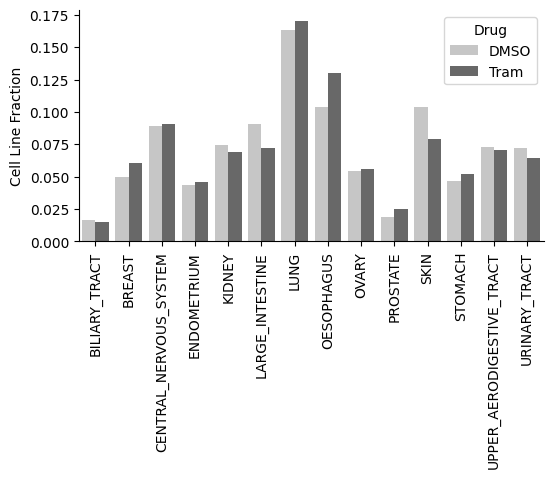

In [6]:
# Get cell line distributions
dfs = []
for drug in ('DMSO', 'Tram'):
    df = adata[adata.obs['Drug'] == drug].obs.groupby(['cell_line'], observed=True).size().reset_index().sort_values(0)
    df = df.rename(columns={'cell_line': 'Cell Line', 0: 'Cell Line Count'})
    df['Cell Line Fraction'] = df['Cell Line Count'] / df['Cell Line Count'].sum()
    df['Drug'] = drug
    dfs.append(df)
dfs = pd.concat(dfs, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(6, 3), sharey=True)
sns.barplot(dfs, x='Cell Line', y='Cell Line Fraction', hue='Drug', palette='Grays', ax=ax)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel(None)
sns.despine(ax=ax)
fig.savefig('../plots/drugseries/Cell_Line_Distribution.pdf')

## Perform Knockdown Simulation

In [7]:
# Get untreated
untreated_idx = adata.obs_names[np.argwhere(common_mask * (adata.obs['treatment'] == untreated_target)).flatten()]
untreated_raw = np.array(adata[untreated_idx].X.todense())
untreated_norm = preprocess_raw_to_norm(untreated_raw)
untreated_pre = preprocess_norm_to_pre(untreated_norm)
env = celltrip.environment.EnvironmentBase(
    torch.tensor(untreated_pre), compute_rewards=False, dim=32).eval(time_scale=5).to('cuda')

# Compute steady state
ret = celltrip.train.simulate_until_completion(
    env, policy, skip_states=100, store_states='cpu', progress_bar=True)
untreated_steady_lat = ret[-1][-1]
untreated_steady_lat_pos = untreated_steady_lat[..., :env.dim]
with torch.no_grad(): untreated_steady_gex_pre = policy.pinning[0](untreated_steady_lat_pos.to('cuda')).detach().cpu().numpy()
untreated_steady_gex_norm = preprocess_pre_to_norm(untreated_steady_gex_pre)

6400it [02:26, 43.73it/s] 


In [8]:
# NOTE: All genes with zeros somehow works???! Albeit low pdelta

In [ ]:
# Compute knockdown
skip_states = 8  # 32 - was 8 for previews
sim_time = skip_states * 4.  # 128. for skip_states=32
# adata.var.loc[adata.var['gene_name'] == 'NF1']
# (adata.var['gene_name'].str.contains('RAF1')).sum()

# Get gene targets
gene_idx = adata.var_names[adata.var['gene_name'].isin(gene_names)].to_numpy().astype(int)  # Use only genes of interest
# gene_idx = np.arange(adata.shape[1])  # Use all genes

# Compute feature targets
knocked_idx = adata.obs_names[np.argwhere(common_mask * (adata.obs['treatment'] == knocked_target)).flatten()]
knocked_raw = np.array(adata[knocked_idx].X.todense())
knocked_norm = preprocess_raw_to_norm(knocked_raw)
mean_un = untreated_raw[:, gene_idx].mean(keepdims=True, axis=0)
mean_ko = knocked_raw[:, gene_idx].mean(keepdims=True, axis=0)
std_un = untreated_raw[:, gene_idx].std(keepdims=True, axis=0)
std_ko = knocked_raw[:, gene_idx].std(keepdims=True, axis=0)
train_idx = adata.obs_names[np.argwhere(adata.obs[train_mask_col]).flatten()]
# Final definition
# feature_targets = np.zeros((1, len(gene_idx)))  # Replace with zeros
feature_targets = knocked_norm[knocked_idx.isin(train_idx)][:, gene_idx].mean(axis=0)  # Compute mean (NORMAL)
# feature_targets = np.expand_dims(feature_targets, 0).repeat(944, 0).shape  # Shape matching, not needed
# feature_targets = np.clip((untreated_data[:, gene_idx] - mean_un) / std_un * std_ko + mean_ko, 0, None)  # Distribution matching

# Time series feature targets
feature_targets_timeseries = []
for temp_target in [untreated_target] + [f'Tram_{i}hr' for i in (3, 6, 12, 24, 48)]:
    temp_data = np.array(
        adata[np.argwhere(
            common_mask * (adata.obs['treatment'] == temp_target)).flatten()]
            .X.todense())
    feature_targets_timeseries.append(temp_data[:, gene_idx].mean(axis=0))
feature_targets_timeseries = np.stack(feature_targets_timeseries, axis=0)
def interp(time):
    return np.array([
                np.interp(time, np.linspace(0, sim_time, 6), feature_targets_timeseries[:, i])
                for i in range(feature_targets_timeseries.shape[1])]),
def nearest(time):
    inverse_idx = (time <= np.linspace(0, sim_time, 6)[1:]).sum()
    return feature_targets_timeseries[-inverse_idx]
def decline(time):
    return feature_targets_timeseries[0] * (1 - time / sim_time)


# CLI
mean_un = untreated_raw[:, gene_idx].mean()
mean_knock = (knocked_raw[:, gene_idx] - untreated_raw[:, gene_idx].mean(axis=0)).mean()
print(f'Observed a mean difference under knockdown of {mean_knock:.2f} from a mean of {mean_un:.2f}')

## Perform simulation
# Set steady state and time
env.reset().set_max_time(sim_time)
env.set_state(untreated_steady_lat.to('cuda'))
              
# DMSO
# dmso_data = np.array(adata[np.argwhere(adata.obs['treatment'] == 'DMSO_48hr').flatten()].X.todense())
# dmso_data = preprocess_common(dmso_data)  # TESTING
# # dmso_offset = dmso_data.mean(keepdims=True, axis=0) - untreated_data.mean(keepdims=True, axis=0)
# dmso_offset = preprocessing.transform([dmso_data])[0].mean(keepdims=True, axis=0) - preprocessing.transform([untreated_data])[0].mean(keepdims=True, axis=0)
# env.modality_offsets[0] += torch.tensor(dmso_offset).to('cuda')

# Run
ret = celltrip.train.simulate_until_completion(
    env, policy,
    env_hooks=[
        # celltrip.utility.hooks.clamp_input_features_hook(
        celltrip.utility.hooks.clamp_input_features_hook(
            gene_idx, preprocessing, feature_targets=feature_targets, modality_idx=0, steps=[],
            device=env.device),  # (NORMAL USAGE)  TODO: Add STEPS arg to manager
        # celltrip.utility.hooks.clamp_inverted_features_hook(
        #     gene_idx, preprocessing, feature_targets=feature_targets, modality_idx=0),
        # celltrip.utility.hooks.continuous_feature_targets(
        #     celltrip.utility.hooks.clamp_input_features_hook,
        #     # celltrip.utility.hooks.clamp_inverted_features_hook,
        #     interp,
        #     gene_idx, preprocessing, modality_idx=0,
        #     device=env.device,
        # ),
    ],
    action_hooks=[
        # celltrip.utility.hooks.move_toward_targets_hook(
        #     gene_idx, feature_targets=0., pinning=policy.pinning[0],
        #     preprocessing=preprocessing, modality_idx=0,
        #     factor=1., device=env.device),
        # celltrip.utility.hooks.move_toward_targets_hook(
        #     gene_idx, feature_targets=feature_targets, pinning=policy.pinning[0],
        #     preprocessing=preprocessing, modality_idx=0,
        #     factor=1., device=env.device),
        # celltrip.utility.hooks.continuous_feature_targets(
        #     celltrip.utility.hooks.move_toward_targets_hook,
        #     decline,
        #     gene_idx, pinning=policy.pinning[0],
        #     preprocessing=preprocessing, modality_idx=0,
        #     factor=1., device=env.device)
    ],
    skip_states=skip_states, store_states='cpu', progress_bar=True)

# Convert
knocked_timeseries_lat = ret[-1]
knocked_timeseries_lat_pos, knocked_timeseries_lat_vel = knocked_timeseries_lat[..., :env.dim], knocked_timeseries_lat[..., env.dim:]
with torch.no_grad(): knocked_timeseries_gex_pre = policy.pinning[0](knocked_timeseries_lat_pos.to('cuda')).detach().cpu().numpy()
knocked_timeseries_gex_norm = preprocess_pre_to_norm(knocked_timeseries_gex_pre)

Observed a mean difference under knockdown of -0.09 from a mean of 0.99


320it [02:21,  2.26it/s]


## Method Comparison

In [10]:
# Save for use by perturbation methods
# adata[common_mask].write_h5ad('../plots/drugseries/tram_data.h5ad')

In [11]:
# Load other methods
methods = ('GEARS', 'CPA')
perturbations = {}
perturbations['Unperturbed'] = untreated_norm.mean(axis=0)
perturbations['Perturbed'] = knocked_norm.mean(axis=0)
perturbations['CellTRIP (No Adj.)'] = knocked_timeseries_gex_norm[-1].mean(axis=0)
perturbations['CellTRIP (Steady-State Adj.)'] = knocked_timeseries_gex_norm[-1].mean(axis=0) - (knocked_timeseries_gex_norm[0].mean(axis=0) - perturbations['Unperturbed'])
perturbations['CellTRIP (PCA Adj.)'] = knocked_timeseries_gex_norm[-1].mean(axis=0) - (preprocess_norm_to_norm(perturbations['Unperturbed'].reshape(1, -1)).flatten() - perturbations['Unperturbed'])
for method in methods:
    pert = np.load(f'../plots/drugseries/{method}_perturbation.npy')
    perturbations[method] = pert
perturbations['Only Targets'] = perturbations['Unperturbed'].copy()
perturbations['Only Targets'][gene_idx] = perturbations['Perturbed'][gene_idx]

In [12]:
# Compute results
results = []

for method in list(perturbations.keys())[2:]:
    # Variables
    pert_method = perturbations[method]
    pert_pert = perturbations['Perturbed']
    pert_unpert = perturbations['Unperturbed']

    # Evaluations
    mse = np.square(pert_method - pert_pert).mean()
    delta = pert_method - pert_unpert
    actual_delta = pert_pert - pert_unpert
    pdelta = np.corrcoef(delta, actual_delta)[0, 1]
    
    # Record
    results.append({'Method': method, 'MSE': mse, 'Pearson Delta': pdelta, 'Mean Abs Delta': np.abs(delta).mean()})
results = pd.DataFrame(results)
results  # Raw MSE and Rel PDelta are most real

,Method,MSE,Pearson Delta,Mean Abs Delta
0,CellTRIP (No Adj.),0.322270,0.195707,0.369414
1,CellTRIP (Steady-State Adj.),0.304043,0.213054,0.359141
2,CellTRIP (PCA Adj.),0.322553,0.190602,0.369119
3,GEARS,0.086412,0.446334,0.155490
4,CPA,74.267670,-0.107098,0.747163
5,Only Targets,0.000000,1.000000,0.063544


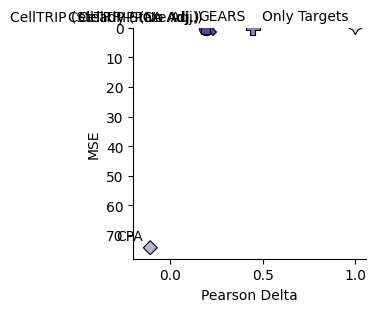

In [13]:
# Method comparison
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
x_var, y_var = 'Pearson Delta', 'MSE'
colors = sns.color_palette('Purples_r', len(results)-2)
colors = 3*[colors[0]] + colors[1:]
sns.scatterplot(
    results, x=x_var, y=y_var, hue='Method',
    hue_order=list(perturbations.keys())[2:], style='Method',
    palette=colors, edgecolor='black', s=100, ax=ax, legend=False)
ax.set_xlim(left=-.2)
ax.set_ylim(bottom=0)
ax.invert_yaxis()
for method in list(perturbations.keys())[2:]:
    row = results.loc[results['Method']==method]
    data_to_axis = ax.transData + ax.transAxes.inverted()
    x, y = data_to_axis.transform([row[x_var], row[y_var]]).flatten()
    ax.text(x-.03, y+.02, method, ha='right', va='bottom', transform=ax.transAxes)
sns.despine(ax=ax)
fig.savefig('../plots/drugseries/Method_Comparison.pdf')

In [14]:
# 'DrugSeries-251113-pip' with only `clamp_input_features_hook` at `0`

# Comparison Statistics

In [15]:
import numpy as np


# Normalization function
def normalize_counts(counts, stats=None, sample_count=10_000, log1p=True):
    # Sample count normalization
    if sample_count is not None:
        counts = sample_count * counts / counts.sum(axis=-1, keepdims=True)

    # Log transformation
    if log1p:
        counts = np.log1p(counts)

    # Get standardization parameters
    if stats is None:
        mean = counts.mean(axis=0, keepdims=True)
        std = counts.std(axis=0, keepdims=True)
        std = np.where(std == 0, 1, std)
    else:
        mean, std = stats
    
    # Standardize
    counts = (counts - mean) / std

    return counts, (mean, std)

# Mean MSE difference between perturbed and predicted distributions
def mean_mse_diff(perturbed, predicted):
    perturbed_mean = perturbed.mean(axis=0)
    predicted_mean = predicted.mean(axis=0)
    mse_diff = np.square(perturbed_mean - predicted_mean).mean()

    return mse_diff

# Pearson correlation between mean changes in true and predicted distributions
def pearson_delta(unperturbed_true, perturbed_true, perturbed_pred, unperturbed_pred=None):
    # Defaults
    unperturbed_pred = unperturbed_true if unperturbed_pred is None else unperturbed_pred

    # Compute deltas
    true_delta = perturbed_true.mean(axis=0) - unperturbed_true.mean(axis=0)
    pred_delta = perturbed_pred.mean(axis=0) - unperturbed_pred.mean(axis=0)
    pdelta = np.corrcoef(true_delta, pred_delta)[0, 1]

    return pdelta

# Wasserstein distance between perturbed and predicted distributions
def wasserstein_distance(perturbed, predicted):
    # Scipy method
    # from scipy.stats import wasserstein_distance_nd
    # return wasserstein_distance_nd(perturbed, predicted)

    # OT method
    import ot
    a, b = ot.utils.unif(perturbed.shape[0]), ot.utils.unif(predicted.shape[0])
    M_raw = ot.dist(perturbed, predicted, metric='sqeuclidean')
    OT_mat = ot.emd(a, b, M_raw / M_raw.max(), numItermax=1_000_000)
    
    return np.sqrt((OT_mat * M_raw).sum())

# Generate fake data
np.random.seed(42)
unperturbed_counts_train = np.random.randint(0, 8192, (13, 100))
perturbed_counts_train = np.random.randint(0, 8192, (17, 100))
unperturbed_counts_val = np.random.randint(0, 8192, (19, 100))
perturbed_counts_val = np.random.randint(0, 8192, (23, 100))

# Normalize training data
gex_train, stats = normalize_counts(
    np.concatenate([unperturbed_counts_train, perturbed_counts_train], axis=0))
unperturbed_gex_train, perturbed_gex_train = gex_train[:unperturbed_counts_train.shape[0]], gex_train[unperturbed_counts_train.shape[0]:]

# Normalize validation data using training stats
gex_val, _ = normalize_counts(
    np.concatenate([unperturbed_counts_val, perturbed_counts_val], axis=0), stats=stats)
unperturbed_gex_val, perturbed_gex_val = gex_val[:unperturbed_counts_val.shape[0]], gex_val[unperturbed_counts_val.shape[0]:]

# Run pipeline to predict perturbed validation from unperturbed validation
perturbed_gex_val_pred = perturbed_gex_val + .1 * np.random.rand(*perturbed_gex_val.shape)  # EXAMPLE PREDICTION, REPLACE

# Compute metrics
mse_diff = mean_mse_diff(perturbed_gex_val, perturbed_gex_val_pred)
pdelta = pearson_delta(unperturbed_gex_val, perturbed_gex_val, perturbed_gex_val_pred)
wass_dist = wasserstein_distance(perturbed_gex_val, perturbed_gex_val_pred)
print(f'MSE Diff: {mse_diff:.4f}, Pearson Delta: {pdelta:.4f}, Wasserstein Distance: {wass_dist:.4f}')

# MSE Diff: 0.0025, Pearson Delta: 0.9998, Wasserstein Distance: 0.5717

MSE Diff: 0.0025, Pearson Delta: 0.9998, Wasserstein Distance: 0.5717


In [16]:
# Plug in CellTRIP predictions
unperturbed_gex_val = untreated_norm
perturbed_gex_val = knocked_norm
unperturbed_gex_val_pred = knocked_timeseries_gex_norm[0]
perturbed_gex_val_pred = knocked_timeseries_gex_norm[-1]

# Get PCA degredation
unperturbed_gex_val_pca = preprocess_norm_to_norm(unperturbed_gex_val)
perturbed_gex_val_pca = preprocess_norm_to_norm(perturbed_gex_val)

# Normalize base data and CellTRIP predictions to mean-centered
# mask_name = 'train_' + untreated_target.lower().split('_')[0] + '_' + knocked_target.lower().split('_')[1]  #  * ~adata.obs['train'] (TODO: Use this?)
_, stats = normalize_counts(np.array(adata[adata.obs[train_mask_col]].X.todense()))
unperturbed_gex_val, _ = normalize_counts(
    preprocess_norm_to_raw(unperturbed_gex_val),  # Doesn't do sample norm
    sample_count=None, stats=stats)
perturbed_gex_val, _ = normalize_counts(
    preprocess_norm_to_raw(perturbed_gex_val),
    sample_count=None, stats=stats)
unperturbed_gex_val_pred, _ = normalize_counts(
    preprocess_norm_to_raw(unperturbed_gex_val_pred),
    sample_count=None, stats=stats)
perturbed_gex_val_pred, _ = normalize_counts(
    preprocess_norm_to_raw(perturbed_gex_val_pred),
    sample_count=None, stats=stats)
unperturbed_gex_val_pca, _ = normalize_counts(
    preprocess_norm_to_raw(unperturbed_gex_val_pca),
    sample_count=None, stats=stats)
perturbed_gex_val_pca, _ = normalize_counts(
    preprocess_norm_to_raw(perturbed_gex_val_pca),
    sample_count=None, stats=stats)

# Get validation mask and apply
# val_mask, val_mask_pert = ~adata[untreated_idx].obs['train'], ~adata[knocked_idx].obs['train']
val_mask, val_mask_pert = ~adata[untreated_idx].obs[train_mask_col], ~adata[knocked_idx].obs[train_mask_col]  # TODO: Double check and maybe revise
if sum(val_mask) == 0:
    val_mask = ~val_mask
if sum(val_mask_pert) == 0:
    val_mask_pert = ~val_mask_pert
unperturbed_gex_train, unperturbed_gex_val = unperturbed_gex_val[~val_mask], unperturbed_gex_val[val_mask]
perturbed_gex_train, perturbed_gex_val = perturbed_gex_val[~val_mask_pert], perturbed_gex_val[val_mask_pert]
unperturbed_gex_train_pred, unperturbed_gex_val_pred = unperturbed_gex_val_pred[~val_mask], unperturbed_gex_val_pred[val_mask]
perturbed_gex_train_pred, perturbed_gex_val_pred = perturbed_gex_val_pred[~val_mask], perturbed_gex_val_pred[val_mask]  # Use `val_mask` since it's predicted from unperturbed data
unperturbed_gex_train_pca, unperturbed_gex_val_pca = unperturbed_gex_val_pca[~val_mask], unperturbed_gex_val_pca[val_mask]
perturbed_gex_train_pca, perturbed_gex_val_pca = perturbed_gex_val_pca[~val_mask_pert], perturbed_gex_val_pca[val_mask_pert]

# Compute metrics and report
# TODO: Use `train=False` for DMSO init
mse_diff = mean_mse_diff(perturbed_gex_val, perturbed_gex_val_pred)
pdelta = pearson_delta(unperturbed_gex_val, perturbed_gex_val, perturbed_gex_val_pred)
pdelta_pred = pearson_delta(unperturbed_gex_val, perturbed_gex_val, perturbed_gex_val_pred, unperturbed_gex_val_pred)
pdelta_pca = pearson_delta(unperturbed_gex_val_pca, perturbed_gex_val_pca, perturbed_gex_val_pred, unperturbed_gex_val_pred)
wass_dist = wasserstein_distance(perturbed_gex_val, perturbed_gex_val_pred)
print(
    f'MSE Diff: {mse_diff:.4f}, '
    f'Pearson Delta: {pdelta:.4f}, '
    f'Pearson Delta Pred: {pdelta_pred:.4f}, '
    f'Pearson Delta PCA Correction: {pdelta_pca:.4f}, '
    f'Wasserstein Distance: {wass_dist:.4f}')

# Full model, zero targets, Untreated start
# 3hr: 
# 6hr: 
# 12hr: 
# 24hr: 
# 48hr: MSE Diff: 0.0217, Pearson Delta: 0.2518, Pearson Delta Pred: 0.0028, Pearson Delta PCA Correction: -0.0439, Wasserstein Distance: 184.7940

# Full model, zero targets, DMSO 48hr start
# 3hr: 
# 6hr: 
# 12hr: 
# 24hr: 
# 48hr: MSE Diff: 0.0223, Pearson Delta: 0.0781, Pearson Delta Pred: 0.0010, Pearson Delta PCA Correction: -0.0275, Wasserstein Distance: 198.0154

# Limited data, zero targets, DMSO 48hr start
# 3hr: 
# 6hr: 
# 12hr: 
# 24hr: 
# 48hr: MSE Diff: 0.0178, Pearson Delta: 0.3145, Pearson Delta Pred: 0.1590, Pearson Delta PCA Correction: 0.1309, Wasserstein Distance: 197.6029

# Limited data, post ALL feature targets, DMSO 48hr start
# 3hr: 
# 6hr: 
# 12hr: 
# 24hr: 
# 48hr: 

# Full model, ALL feature targets, DMSO 48hr start
# 3hr: MSE Diff: 0.0098, Pearson Delta: 0.3763, Pearson Delta Pred: 0.1023, Pearson Delta PCA Correction: 0.3935, Wasserstein Distance: 168.4811
# 6hr: MSE Diff: 0.0116, Pearson Delta: 0.3601, Pearson Delta Pred: 0.1780, Pearson Delta PCA Correction: 0.4510, Wasserstein Distance: 200.7106
# 12hr: MSE Diff: 0.0110, Pearson Delta: 0.4329, Pearson Delta Pred: 0.2734, Pearson Delta PCA Correction: 0.5099, Wasserstein Distance: 185.3660
# 24hr: MSE Diff: 0.0059, Pearson Delta: 0.7139, Pearson Delta Pred: 0.6609, Pearson Delta PCA Correction: 0.7252, Wasserstein Distance: 178.3463
# 48hr: MSE Diff: 0.0104, Pearson Delta: 0.6841, Pearson Delta Pred: 0.6628, Pearson Delta PCA Correction: 0.7952, Wasserstein Distance: 199.8287

# Full model, ALL feature targets, DMSO 48hr start, proper masking
# 3hr: MSE Diff: 0.0091, Pearson Delta: 0.3901, Pearson Delta Pred: 0.1204, Pearson Delta PCA Correction: 0.4306, Wasserstein Distance: 164.5368
# 6hr: MSE Diff: 0.0112, Pearson Delta: 0.3628, Pearson Delta Pred: 0.1797, Pearson Delta PCA Correction: 0.4639, Wasserstein Distance: 196.1266
# 12hr: MSE Diff: 0.0096, Pearson Delta: 0.4678, Pearson Delta Pred: 0.2969, Pearson Delta PCA Correction: 0.5423, Wasserstein Distance: 175.6903
# 24hr: NA
# 48hr: MSE Diff: 0.0100, Pearson Delta: 0.6942, Pearson Delta Pred: 0.6708, Pearson Delta PCA Correction: 0.8027, Wasserstein Distance: 193.8931

# Limited data, ALL feature targets, DMSO 48hr start
# 3hr: MSE Diff: 0.0140, Pearson Delta: 0.3539, Pearson Delta Pred: 0.1653, Pearson Delta PCA Correction: 0.2926, Wasserstein Distance: 169.4524
# 6hr: MSE Diff: 0.0144, Pearson Delta: 0.3411, Pearson Delta Pred: 0.1306, Pearson Delta PCA Correction: 0.2449, Wasserstein Distance: 201.3819
# 12hr: MSE Diff: 0.0108, Pearson Delta: 0.4632, Pearson Delta Pred: 0.2213, Pearson Delta PCA Correction: 0.4000, Wasserstein Distance: 185.8578
# 24hr: MSE Diff: 0.0068, Pearson Delta: 0.6290, Pearson Delta Pred: 0.4821, Pearson Delta PCA Correction: 0.5324, Wasserstein Distance: 178.2501
# 48hr: 

# Limited data, feature targets, DMSO 48hr start
# 3hr: MSE Diff: 0.0121, Pearson Delta: 0.2992, Pearson Delta Pred: -0.0145, Pearson Delta PCA Correction: -0.1524, Wasserstein Distance: 165.4154
# 6hr: MSE Diff: 0.0158, Pearson Delta: 0.2266, Pearson Delta Pred: -0.1049, Pearson Delta PCA Correction: -0.1562, Wasserstein Distance: 198.6081
# *12hr: MSE Diff: 0.0130, Pearson Delta: 0.2226, Pearson Delta Pred: -0.1442, Pearson Delta PCA Correction: -0.2252, Wasserstein Distance: 175.4039
# *24hr: MSE Diff: 0.0126, Pearson Delta: 0.2284, Pearson Delta Pred: -0.1240, Wasserstein Distance: 194.2227
# 48hr: MSE Diff: 0.0201, Pearson Delta: 0.1876, Pearson Delta Pred: -0.0927, Pearson Delta PCA Correction: -0.0565, Wasserstein Distance: 197.7086

MSE Diff: 0.3298, Pearson Delta: 0.1967, Pearson Delta Pred: 0.1878, Pearson Delta PCA Correction: 0.2001, Wasserstein Distance: 219.1037


In [17]:
pearson_delta(
    unperturbed_gex_val, perturbed_gex_val,
    perturbed_gex_val_pred
    # + (perturbed_gex_train.mean(axis=0, keepdims=True) - unperturbed_gex_train.mean(axis=0, keepdims=True)) - (perturbed_gex_train_pca.mean(axis=0, keepdims=True) - unperturbed_gex_train_pca.mean(axis=0, keepdims=True))
    # + (perturbed_gex_train  - perturbed_gex_train_pca).mean(axis=0, keepdims=True) - (unperturbed_gex_train - unperturbed_gex_train_pca).mean(axis=0, keepdims=True)
)

np.float64(0.19672928961520503)

## Visualize

In [18]:
# Calculate pdelta results
# eps = 30  # Minimum var difference for which we should compute correlation
all_treatments = [f'Tram_{t}' for t in timesteps]  # [1:]
pdelta_results = pd.DataFrame(index=all_treatments, columns=skip_states*np.arange(knocked_timeseries_lat.shape[0]), dtype=float)
pert_diffs = []
for treatment in pdelta_results.index:
    # Get actual perturbation delta
    pert_idx = adata.obs_names[np.argwhere(common_mask * (adata.obs['treatment'] == treatment)).flatten()]
    pert_raw = np.array(adata[pert_idx].X.todense())
    pert_norm = preprocess_raw_to_norm(pert_raw)
    pert_diff = pert_norm.mean(axis=-2) - untreated_norm.mean(axis=-2)
    pert_diffs.append(pert_diff)

    # Get predicted perturbation delta
    pred_diff = knocked_timeseries_gex_norm.mean(axis=-2) - np.expand_dims(untreated_norm, axis=0).mean(axis=-2)
    # pred_diff = knocked_gex.mean(axis=-2) - np.expand_dims(untreated_data, axis=0).mean(axis=-2)
    # pred_diff = knocked_gex.mean(axis=-2) - np.expand_dims(preprocess_common(untreated_data), axis=0).mean(axis=-2)
    # pred_diff = knocked_gex.mean(axis=-2) - knocked_gex[[5]].mean(axis=-2)
    # pred_diff_nan_mask = np.abs(pred_diff).mean(axis=-1) < eps
    # pred_diff_nan_mask = pred_diff.var(axis=-1) < eps

    # Calculate pearson delta for prediction
    pdelta = np.corrcoef(np.expand_dims(pert_diff, axis=0), pred_diff)[0, 1:]  # Not optimal, pdelta
    # pdelta = -np.square(np.expand_dims(pert_diff, axis=0) - pred_diff).mean(axis=-1)  # MSE
    pdelta_results.loc[treatment] = pdelta
    # pdelta_results.loc[treatment, pred_diff_nan_mask] = np.nan  # Mask out unreliably low perturbations

    # Calculate pearson delta for actual
    pdelta = np.corrcoef(np.expand_dims(pert_diff, axis=0), pred_diff)

# Crop first and last timestep - same as untreated and uneven step, respectively
# pdelta_results = pdelta_results.iloc[:, 1:-1]

# Get pearson delta for actual
pert_diffs = np.stack(pert_diffs, axis=0)
pdelta = np.corrcoef(pert_diffs)
pdelta_actual = pd.DataFrame(pdelta, index=all_treatments, columns=all_treatments, dtype=float)

# Normalize
# pdelta_results_norm = (pdelta_results - pdelta_results.to_numpy().mean(keepdims=True, axis=1)) / pdelta_results.to_numpy().std(keepdims=True, axis=1)
# pdelta_actual_norm = (pdelta_actual - pdelta_actual.to_numpy().mean(keepdims=True, axis=1)) / pdelta_actual.to_numpy().nanstd(keepdims=True, axis=1)
pdelta_results_rownorm = (pdelta_results - np.nanmean(pdelta_results.to_numpy(), keepdims=True, axis=1)) / np.nanstd(pdelta_results.to_numpy(), keepdims=True, axis=1)
pdelta_actual_rownorm = (pdelta_actual - np.nanmean(pdelta_actual.to_numpy(), keepdims=True, axis=1)) / np.nanstd(pdelta_actual.to_numpy(), keepdims=True, axis=1)
pdelta_results_colnorm = (pdelta_results - np.nanmean(pdelta_results.to_numpy(), keepdims=True, axis=0)) / np.nanstd(pdelta_results.to_numpy(), keepdims=True, axis=0)
pdelta_actual_colnorm = (pdelta_actual - np.nanmean(pdelta_actual.to_numpy(), keepdims=True, axis=0)) / np.nanstd(pdelta_actual.to_numpy(), keepdims=True, axis=0)
pdelta_results_diff = pdelta_results - pdelta_results.to_numpy()[:, [0]]
pdelta_actual_diff = pdelta_actual - pdelta_actual.to_numpy()[:, [0]]
pdelta_results_diff_rowscale = pdelta_results_diff / np.nanstd(pdelta_results_diff.to_numpy(), keepdims=True, axis=1)
pdelta_actual_diff_rowscale = pdelta_actual_diff / np.nanstd(pdelta_actual_diff.to_numpy(), keepdims=True, axis=1)
# pdelta_results_norm = (pdelta_results - pdelta_results.to_numpy().min(keepdims=True, axis=1)) / (pdelta_results.to_numpy().max(keepdims=True, axis=1) - pdelta_results.to_numpy().min(keepdims=True, axis=1))
# pdelta_actual_norm = (pdelta_actual - pdelta_actual.to_numpy().min(keepdims=True, axis=1)) / (pdelta_results.to_numpy().max(keepdims=True, axis=1) - pdelta_results.to_numpy().min(keepdims=True, axis=1))

/tmp/ipykernel_192160/1798063853.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  velocity_density = np.sqrt(knocked_timeseries_lat_vel.square().sum(dim=-1)).mean(dim=-1)  # Euclidean norm


Using Kernel Size 13
Using Kernel Size 13
Using Kernel Size 13
Using Kernel Size 13


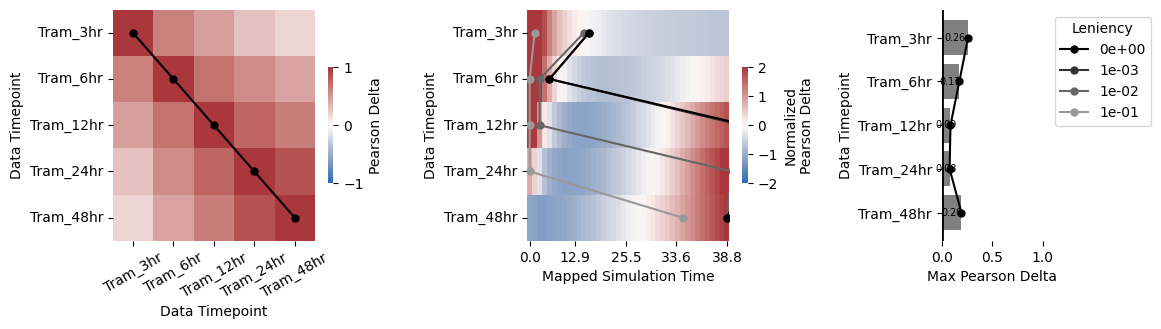

In [19]:
# Create figure
widths = [5, 5, 2]
line_kwargs = dict(marker='o', markersize=6, markeredgecolor='none')
fig, axs = plt.subplots(1, 3, figsize=(sum(widths), 3), width_ratios=widths)
fig.subplots_adjust(wspace=.8)

# Annotate max
num_lines = 4
eps_list = np.concat([np.logspace(-1, -3, num_lines-1, base=10), [0]])
white_list = np.linspace(.6, 0., num_lines)
def get_peak(df, kernel_size=None, eps=1e-2):
    # Default params
    if kernel_size is None:
        kernel_size = np.ceil((10/sim_time)*df.shape[1]).astype(int)
        print(f'Using Kernel Size {kernel_size}')
    # Moving window
    smoothed = np.stack([
        np.convolve(df.to_numpy()[i], np.ones(kernel_size) / kernel_size, mode='full')
        for i in range(df.shape[0])], axis=0)
    return (smoothed >= smoothed.max(keepdims=True, axis=1) - eps).argmax(axis=1)
    # return smoothed.argmax(axis=1)
    # Weighted mean
    # data = df.to_numpy()
    # data = (data - data.min(keepdims=True, axis=1)) / data.std(keepdims=True, axis=1)  # / (data.max(keepdims=True, axis=1) - data.min(keepdims=True, axis=1))
    # data = np.exp(data)  # Scaling exp
    # data = data / data.sum(keepdims=True, axis=1)
    # return (data * np.expand_dims(np.arange(data.shape[1]), axis=0)).sum(axis=1)
    # First to max-eps
    # return (df.to_numpy() >= df.to_numpy().max(keepdims=True, axis=1) - eps).argmax(axis=1)
    # Max
    # return df.to_numpy().argmax(axis=1)

# Reference pdelta heatmap
ax = axs[0]
sns.heatmap(
    pdelta_actual,
    cmap='vlag', vmin=-1, vmax=1,
    cbar_kws={
        'shrink': .5, 'ticks': np.arange(-1, 1.01, 1.),
        'label': 'Pearson Delta'}, ax=ax)
ax.set(xlabel='Data Timepoint', ylabel='Data Timepoint')
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
# Annotate max
ax.plot(
    get_peak(pdelta_actual, kernel_size=1, eps=0) + .5,
    np.arange(pdelta_actual.shape[0]) + .5,
    color='black', **line_kwargs)

# Compute biological time map
# velocity_density = knocked_timeseries_lat_vel.abs().mean(dim=(-1, -2))  # Mean abs - normal
velocity_density = np.sqrt(knocked_timeseries_lat_vel.square().sum(dim=-1)).mean(dim=-1)  # Euclidean norm
# velocity_density = np.log(1 + velocity_density)  # TODO: TESTING
sim_timesteps = np.full(len(velocity_density), skip_states * env.delta).cumsum() - skip_states * env.delta
map_func = celltrip.utility.mapping.compute_sim_bio_mapping(
    velocity_density, sim_timesteps, start_val=0, end_val=48
)
# bio_time = map_func(sim_timesteps)

# Actual pdelta heatmap
ax = axs[1]
# df_use = pdelta_results
df_use = pdelta_results_rownorm
# df_use = pdelta_results_colnorm
# df_use = pdelta_results_diff
# df_use = pdelta_results_diff_rowscale
sns.heatmap(
    df_use,
    cmap='vlag',
    vmin=-2, vmax=2,
    cbar_kws={
        'shrink': .5,
        'ticks': np.arange(-2, 2.01, 1.),
        'label': 'Normalized\nPearson Delta'}, ax=ax)
ax.set(xlabel='Mapped Simulation Time', ylabel='Data Timepoint')  # Simulation Time, previously
xtick_step = df_use.shape[1] / 4
xticks = np.array([1] + np.arange(
    xtick_step, xtick_step*(1+df_use.shape[1]//xtick_step), xtick_step).tolist()) - .5
xticklabels = skip_states * env.delta * (xticks + .5)
xticklabels = map_func(xticklabels)
xticklabels = [f'{l:.1f}' for l in xticklabels]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)
# Annotate max
for eps, white in zip(eps_list, white_list):
    ax.plot(
        get_peak(pdelta_results, eps=eps) + .5,
        np.arange(pdelta_results.shape[0]) + .5,
        color=3*[white], **line_kwargs)

# Peak performance
ax = axs[2]
pdelta_results_max = pdelta_results.max(axis=1).reset_index()
pdelta_results_max.columns = ['Data Timepoint', 'Max Pearson Delta']
bar = sns.barplot(pdelta_results_max, x='Max Pearson Delta', y='Data Timepoint', orient='y', color='gray', ax=ax)
sns.lineplot(pdelta_results_max, x='Max Pearson Delta', y='Data Timepoint', orient='y', color='black', **line_kwargs, ax=ax)
ax.bar_label(bar.containers[0], fmt='{:0.2f}', label_type='center', fontsize='x-small')
# ax.set(ylabel=None, yticklabels=[], yticks=[])
ax.set_xlim(right=1.)
# ax.tick_params(axis='x', which='major', length=0)
ax.axvline(x=0, color='black', lw=2)
sns.despine(left=True, bottom=True)

# Make legend
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=3*[white], **line_kwargs, label=f'{eps:.0e}')
    for eps, white in zip(eps_list, white_list)][::-1],
    loc='upper left', bbox_to_anchor=(1.05, 1.), title='Leniency')

fig.savefig('../plots/drugseries/Timed_Pearson_Delta.pdf')

Tram_3hr     1.645181
Tram_6hr     0.647156
Tram_12hr    0.057701
Tram_24hr    0.084842
Tram_48hr    1.646512
dtype: float64


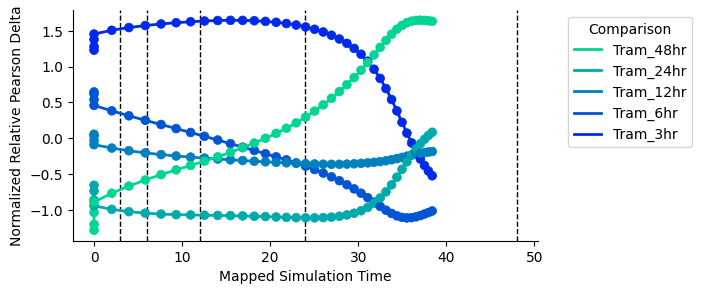

In [20]:
# Min-max normalize
def minmax_normalize(df, axis=1):
    df_min = df.min(axis=axis)
    df_max = df.max(axis=axis)
    return df.sub(df_min, axis=1-axis).div(df_max - df_min, axis=1-axis)

# Sum normalize
def sum_normalize(df, axis=1):
    df_sum = df.sum(axis=axis)
    return df.div(df_sum, axis=1-axis)

# Regular normalize
def regular_normalize(df, axis=1):
    df_mean = df.mean(axis=axis)
    df_std = df.std(axis=axis)
    return df.sub(df_mean, axis=1-axis).div(df_std, axis=1-axis)

# Melt df
# TODO: Maybe look at relative delta
df = pdelta_results.copy()
# df = sum_normalize(df, axis=0)  # Normalize by time col
# df = minmax_normalize(df, axis=0)  # Normalize by time col
df = regular_normalize(df, axis=0)  # Normalize by time col (DEFAULT)
# df = minmax_normalize(df, axis=1)  # Normalize by comparison row
# df = regular_normalize(df, axis=1)  # Normalize by comparison row
# df = regular_normalize(regular_normalize(df, axis=1), axis=0)  # Normalize by comparison row then time col
df.columns = map_func(df.columns * env.delta)
print(df.max(axis=1))
df = df.reset_index(names='Comparison').melt(id_vars='Comparison', var_name='Mapped Simulation Time', value_name='Pearson Delta')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.lineplot(df, x='Mapped Simulation Time', y='Pearson Delta', hue='Comparison', lw=2, palette='winter', ax=ax, zorder=-1)
sns.scatterplot(df, x='Mapped Simulation Time', y='Pearson Delta', hue='Comparison', s=40, edgecolor=None, palette='winter', ax=ax)

# Labels
# ax.set_xlabel('Biological Time (h)')
# ax.set_ylabel('Normalized Pearson Delta')
ax.set_ylabel('Normalized Relative Pearson Delta')

# Add vertical lines at 3, 6, 12, 24, 48 hours
for t in (3, 6, 12, 24, 48):
    ax.axvline(x=t, color='black', lw=1, ls='--', zorder=-2)

# Move legend outside and remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels[::-1], handles[::-1]))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.05, 1.), title='Comparison')

# Stylization
sns.despine()

# Save plot
fig.savefig('../plots/drugseries/Timed_Pearson_Delta_Line.pdf', bbox_inches='tight')

In [21]:
# TRY PCA CORRECTION ON ON ORIGINAL DATA

In [22]:
# 'DrugSeries-251013' with only `clamp_input_features_hook` at `feature_targets`

In [23]:
pdelta_results

,0,8,16,24,32,40,48,56,64,72,...,248,256,264,272,280,288,296,304,312,320
Tram_3hr,0.260737,0.260532,0.220737,0.177100,0.145987,0.124545,0.109339,0.098163,0.089794,0.083255,...,0.038042,0.037671,0.037303,0.036859,0.036311,0.035663,0.034924,0.034112,0.033240,0.032320
Tram_6hr,0.174393,0.160314,0.101676,0.049897,0.015078,-0.008580,-0.025478,-0.038209,-0.048009,-0.055694,...,-0.040279,-0.036407,-0.032323,-0.028170,-0.024046,-0.019996,-0.016046,-0.012211,-0.008499,-0.004916
Tram_12hr,0.086959,0.071435,0.020547,-0.020066,-0.045376,-0.061328,-0.071849,-0.078991,-0.083699,-0.086603,...,-0.003382,0.003979,0.011606,0.019174,0.026484,0.033467,0.040102,0.046390,0.052339,0.057965
Tram_24hr,-0.018565,-0.045053,-0.097494,-0.129019,-0.144974,-0.153233,-0.157603,-0.159665,-0.160076,-0.159184,...,-0.020637,-0.009159,0.002858,0.014882,0.026591,0.037875,0.048696,0.059041,0.068911,0.078316
Tram_48hr,-0.111523,-0.115595,-0.122234,-0.122147,-0.118810,-0.114614,-0.110375,-0.106148,-0.101765,-0.097050,...,0.082869,0.095321,0.108322,0.121514,0.134609,0.147481,0.160064,0.172313,0.184199,0.195707


In [24]:
assert False

AssertionError: 

# Load Data for Comparison

In [3]:
# Load comparison metrics
comparison = pd.read_csv('../plots/drugseries/comparison_performance.csv', index_col=None).iloc[:, :-1]

# Change test set when origin and destination are the same
# is_celltrip = comparison['Method'].str.startswith('CellTRIP')
matches_time = comparison.apply(lambda x: x['Test Set Type'].endswith(x['Model']), axis=1)
app_df = comparison.loc[matches_time].copy()
app_df['Test Set Type'] = 'DMSO:ts'
comparison = pd.concat([comparison, app_df], axis=0, ignore_index=True)

# Remove :48 from untreated
app_df = comparison.loc[comparison['Test Set Type'].str.startswith('Untreated')].copy()
app_df['Test Set Type'] = 'Untreated'
comparison = pd.concat([comparison, app_df], axis=0, ignore_index=True)

# Finalize and filter
comparison = comparison.loc[comparison['Test Set Type'].isin(['Untreated', 'DMSO:48hr', 'DMSO:ts'])]
comparison = comparison.reset_index(drop=True)

In [4]:
# Compute confidence intervals for each statistic, method, and test set type
ci_results = []
for statistic, method, model, test_set in itertools.product(
    ['MSE', 'Pearson Delta', 'Wass Distance'],
    comparison['Method'].unique(),
    comparison['Model'].unique(),
    comparison['Test Set Type'].unique()
):
    subset = comparison[
        (comparison['Method'] == method)
        * (comparison['Model'] == model)
        * (comparison['Test Set Type'] == test_set)]
    if len(subset) > 1:
        mean_value = subset[statistic].mean()
        std_value = subset[statistic].std()
        ci_interval_half = 1.96 * (std_value / np.sqrt(len(subset)))  # 95% CI
        ci_results.append({
            'Method': method,
            'Model': model,
            'Test Set Type': test_set,
            'Statistic': statistic,
            f'Mean': mean_value,
            'CI': ci_interval_half,
            f'CI Lower': mean_value - ci_interval_half,
            f'CI Upper': mean_value + ci_interval_half,
        })

# Convert to dataframe
ci_results = pd.DataFrame(ci_results)

In [5]:
# Subtract `CellTRIP Full` from `CellTRIP Full - PCA Adjusted` across all statistics
mean_results_pivot = ci_results.pivot(index=['Model', 'Test Set Type', 'Statistic'], columns='Method', values='Mean')
mean_results_diff = mean_results_pivot
mean_results_diff['Difference'] = mean_results_diff['CellTRIP Full - PCA Adjusted'] - mean_results_diff['CellTRIP Full']
mean_results_diff = mean_results_diff[['Difference']].reset_index()
mean_results_diff.loc[
    (mean_results_diff['Test Set Type'] == 'DMSO:48hr')
    * (mean_results_diff['Statistic'] == 'Pearson Delta')    
]

# Show differences by test set type and statistic
mean_results_diff.groupby(['Test Set Type', 'Statistic']).agg({'Difference': ['mean', 'std']}).reset_index()

# Get mean pearson delta CI for `CellTRIP Full` on `DMSO:48hr` test set
ci_results_pivot = ci_results.pivot(index=['Model', 'Test Set Type', 'Statistic'], columns='Method', values='CI')
df = ci_results_pivot.reset_index()
df.loc[
    (df['Test Set Type'] == 'DMSO:48hr')
    * (df['Statistic'] == 'Pearson Delta')    
]['CellTRIP Full'].mean()

np.float64(0.06393658212501631)

In [6]:
# Put pivots together in CI form with 3 significant digits
def combine_mean_ci(df_mean, df_ci):
    df_mean = df_mean.map(lambda x: f'{x:.3f}' if pd.notnull(x) else x)
    df_ci = df_ci.map(lambda x: f'±{x:.3f}' if pd.notnull(x) else x)
    results_pivot = df_mean + df_ci
    return results_pivot

# Full
df_full = combine_mean_ci(mean_results_pivot, ci_results_pivot)
# Averaged by model
df_mean = combine_mean_ci(
    mean_results_pivot.reset_index().drop(columns=['Model']).groupby(['Test Set Type', 'Statistic']).mean(),
    ci_results_pivot.reset_index().drop(columns=['Model']).groupby(['Test Set Type', 'Statistic']).mean()).T

In [8]:
for method in ['CellTRIP Full', 'CPA', 'GEARS', 'cellot', 'scVI', 'scGen']:
    print(method)
    df_sub = df_mean.loc[method].reset_index()
    df_sub = df_sub.loc[df_sub['Test Set Type'] == 'DMSO:ts']
    df_sub['Statistic'] = df_sub['Statistic'].map({
        'MSE': 'Mean MSE', 'Pearson Delta': 'Pearson Delta','Wass Distance': 'Wasserstein Distance'})
    print(', '.join([f'{row.Statistic} ${row[2]}$' for i, row in df_sub.iterrows()]))

CellTRIP Full
Mean MSE $0.014±0.004$, Pearson Delta $0.533±0.071$, Wasserstein Distance $185.865±0.370$
CPA
Mean MSE $0.008±0.000$, Pearson Delta $0.138±0.053$, Wasserstein Distance $161.707±1.773$
GEARS
Mean MSE $0.018±0.004$, Pearson Delta $0.547±0.023$, Wasserstein Distance $nan$
cellot
Mean MSE $35667.075±7808.516$, Pearson Delta $0.009±0.004$, Wasserstein Distance $61385.520±9803.672$
scVI
Mean MSE $0.008±0.000$, Pearson Delta $0.678±0.018$, Wasserstein Distance $187.339±1.189$
scGen
Mean MSE $0.007±0.000$, Pearson Delta $0.703±0.020$, Wasserstein Distance $183.296±1.372$


/tmp/ipykernel_207246/1737115692.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(', '.join([f'{row.Statistic} ${row[2]}$' for i, row in df_sub.iterrows()]))
/tmp/ipykernel_207246/1737115692.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(', '.join([f'{row.Statistic} ${row[2]}$' for i, row in df_sub.iterrows()]))
/tmp/ipykernel_207246/1737115692.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(', '.join([

In [15]:
df = df_full.reset_index()
df = df.loc[df['Model'] == '48hr']
df = df.loc[df['Test Set Type'] == 'DMSO:ts']
df[['Statistic', 'CellTRIP Full', 'scVI', 'scGen']].set_index('Statistic').T

Statistic,MSE,Pearson Delta,Wass Distance
Method,,,
CellTRIP Full,0.014±0.005,0.648±0.064,194.798±0.391
scVI,0.012±0.000,0.644±0.001,195.391±0.473
scGen,0.008±0.001,0.754±0.022,191.179±0.423


In [9]:
df_full

Method                                       CPA  CellTRIP Full  \
Model Test Set Type Statistic                                     
12hr  DMSO:48hr     MSE              0.006±0.000    0.015±0.004   
                    Pearson Delta    0.010±0.041    0.402±0.080   
                    Wass Distance  163.480±2.680  176.684±0.373   
      DMSO:ts       MSE              0.006±0.000    0.015±0.004   
                    Pearson Delta    0.167±0.036    0.517±0.075   
                    Wass Distance  161.029±1.637  176.684±0.373   
      Untreated     MSE              0.007±0.000    0.015±0.003   
                    Pearson Delta    0.111±0.040    0.538±0.044   
                    Wass Distance  160.579±2.000  176.682±0.248   
24hr  DMSO:48hr     MSE              0.004±0.000    0.013±0.004   
                    Pearson Delta    0.713±0.018    0.535±0.060   
                    Wass Distance  169.620±2.114  198.128±1.119   
      DMSO:ts       MSE              0.011±0.000    0.013±0.004   
                    Pearson Delta   -0.006±0.059    0.564±0.080   
                    Wass Distance  165.161±0.926  195.248±0.331   
      Untreated     MSE              0.003±0.000    0.014±0.003   
                    Pearson Delta    0.810±0.012    0.564±0.052   
                    Wass Distance  165.085±1.435  198.847±0.228   
3hr   DMSO:48hr     MSE              0.003±0.000    0.014±0.004   
                    Pearson Delta    0.195±0.051    0.342±0.046   
                    Wass Distance  155.752±2.884  165.559±0.391   
      DMSO:ts       MSE              0.003±0.000    0.014±0.004   
                    Pearson Delta    0.247±0.072    0.443±0.062   
                    Wass Distance  156.263±2.024  165.561±0.391   
      Untreated     MSE              0.003±0.000    0.014±0.003   
                    Pearson Delta    0.234±0.046    0.498±0.034   
                    Wass Distance  155.029±2.079  165.557±0.260   
48hr  DMSO:48hr     MSE              0.014±0.000    0.014±0.005   
                    Pearson Delta   -0.075±0.063    0.648±0.064   
                    Wass Distance  172.096±2.704  194.798±0.391   
      DMSO:ts       MSE              0.014±0.000    0.014±0.005   
                    Pearson Delta   -0.030±0.048    0.648±0.064   
                    Wass Distance  170.014±2.095  194.798±0.391   
      Untreated     MSE              0.014±0.000    0.014±0.003   
                    Pearson Delta    0.029±0.052    0.704±0.035   
                    Wass Distance  167.336±2.097  194.796±0.260   
6hr   DMSO:48hr     MSE              0.004±0.000    0.016±0.004   
                    Pearson Delta    0.098±0.046    0.311±0.070   
                    Wass Distance  161.582±2.830  197.033±0.366   
      DMSO:ts       MSE              0.004±0.000    0.016±0.004   
                    Pearson Delta    0.312±0.048    0.492±0.073   
                    Wass Distance  156.070±2.182  197.034±0.366   
      Untreated     MSE              0.004±0.000    0.016±0.003   
                    Pearson Delta    0.178±0.052    0.460±0.040   
                    Wass Distance  158.131±2.043  197.030±0.243   

Method                            CellTRIP Full - PCA Adjusted  \
Model Test Set Type Statistic                                    
12hr  DMSO:48hr     MSE                            0.015±0.004   
                    Pearson Delta                  0.499±0.067   
                    Wass Distance                176.684±0.373   
      DMSO:ts       MSE                            0.015±0.004   
                    Pearson Delta                  0.458±0.071   
                    Wass Distance                176.684±0.373   
      Untreated     MSE                            0.015±0.003   
                    Pearson Delta                  0.508±0.046   
                    Wass Distance                176.682±0.248   
24hr  DMSO:48hr     MSE                            0.013±0.004   
                    Pearson Delta                  0.639±0

In [ ]:
df_mean

,Test Set Type,Statistic,scGen
0,DMSO:48hr,MSE,0.007±0.000
1,DMSO:48hr,Pearson Delta,0.618±0.021
2,DMSO:48hr,Wass Distance,183.407±0.989
3,DMSO:ts,MSE,0.007±0.000
4,DMSO:ts,Pearson Delta,0.703±0.020
5,DMSO:ts,Wass Distance,183.296±1.372
6,Untreated,MSE,0.007±0.000
7,Untreated,Pearson Delta,0.703±0.015
8,Untreated,Wass Distance,183.491±0.827


In [ ]:
assert False

AssertionError: 

# Run Interpolation on 24hr

In [ ]:
# Load sample-normalized model
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110', 700  # 32 dim - sample-normalized
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110-cont', 1600  # 32 dim - sample-normalized
# prefix, training_step = 's3://nkalafut-celltrip/checkpoints/DrugSeries-251110-log', 800  # 32 dim - sample and log normalized (USE)
# preprocessing = celltrip.utility.processing.Preprocessing().load(f'{prefix}.pre')
# policy.load_checkpoint(f'{prefix}-{training_step:04}.weights');

In [ ]:
# adata.obs.groupby('cell_line').size()

In [ ]:
# Determine stages to interpolate
drug, start_time, interp_time, end_time = 'Tram', '12hr', '24hr', '48hr'
start_stage, interp_stage, end_stage = f'{drug}_{start_time}', f'{drug}_{interp_time}', f'{drug}_{end_time}'

# Get known data
common_mask = True
# common_mask = adata.obs['cell_line'] == 'LUNG'
start_exp = np.array(adata[common_mask * (adata.obs['treatment']==start_stage)].X.todense())
interp_exp = np.array(adata[common_mask * (adata.obs['treatment']==interp_stage)].X.todense())
end_exp = np.array(adata[common_mask * (adata.obs['treatment']==end_stage)].X.todense())

# Normalize expression
start_exp = preprocess_raw_to_norm(start_exp)
interp_exp = preprocess_raw_to_norm(interp_exp)
end_exp = preprocess_raw_to_norm(end_exp)

# Use K-Means to create start and end pseudocells
start_n_pcells = end_n_pcells = min([exp.shape[0] for exp in (start_exp, interp_exp, end_exp)])  # 500
start_pcell_ids = sklearn.cluster.KMeans(n_clusters=start_n_pcells, random_state=42).fit_predict(start_exp)
end_pcell_ids = sklearn.cluster.KMeans(n_clusters=end_n_pcells, random_state=42).fit_predict(end_exp)
print(f'Chose {start_n_pcells}-{end_n_pcells} cells')

# Get expression and spatial for pseudocells
start_processed_exp = np.stack([start_exp[np.argwhere(start_pcell_ids==i).flatten()].mean(axis=0) for i in range(start_n_pcells)], axis=0)
end_processed_exp = np.stack([end_exp[np.argwhere(end_pcell_ids==i).flatten()].mean(axis=0) for i in range(end_n_pcells)], axis=0)

# Calculate OT matrix
a, b, _, OT_mat = celltrip.utility.general.compute_discrete_ot_matrix(start_processed_exp, end_processed_exp)

# Calculate pseudocells
pcells = [([i], np.argwhere(OT_mat[i] > 0).flatten()) for i in range(OT_mat.shape[0]) if OT_mat[i].sum() > 0]
start_pcells_exp, end_pcells_exp = [], []
start_pcells_obs, end_pcells_obs = [], []
for pcell_start, pcell_end in pcells:
    start_pcells_exp.append(start_processed_exp[pcell_start].mean(axis=0))
    end_pcells_exp.append(end_processed_exp[pcell_end].mean(axis=0))
start_pcells_exp = np.stack(start_pcells_exp, axis=0)
end_pcells_exp = np.stack(end_pcells_exp, axis=0)

# Run to initial steady state
start_m1, = preprocessing.transform([start_pcells_exp])
env = celltrip.environment.EnvironmentBase(
    torch.tensor(start_m1), compute_rewards=False, dim=env.dim).eval(time_scale=5).to('cuda')
env.reset()
celltrip.train.simulate_until_completion(env, policy, store_states=False, progress_bar=True)

# Get transition states
end_m1, = preprocessing.transform([end_pcells_exp])
env.set_modalities([torch.tensor(end_m1)]).set_max_time(64.).to('cuda')
env.time = 0  # Reset timing
transition_skip = 20
transition_states = celltrip.train.simulate_until_completion(env, policy, skip_states=transition_skip, store_states='cpu', progress_bar=True)[-1].cpu()
transition_states_pos, transition_states_vel = transition_states[..., :env.dim], transition_states[..., env.dim:]
num_even_states = env.max_time / (transition_skip * env.delta)
transition_sim_time = (transition_skip * env.delta * np.arange(num_even_states+1)).tolist()
if num_even_states != int(num_even_states): transition_sim_time += [env.max_time]
transition_sim_time = np.array(transition_sim_time)

# Impute
with torch.no_grad(): transition_states_exp = policy.pinning[0](transition_states_pos.to('cuda')).detach().cpu().numpy()
transition_states_exp = preprocess_pre_to_norm(transition_states_exp)


Chose 948-948 cells


6400it [00:18, 353.23it/s]
640it [00:01, 354.37it/s]


In [ ]:
# Compute velocity density
velocity_density = np.sqrt(transition_states_vel.square().sum(dim=-1)).mean(dim=-1)

# Compute mapping function
map_func = celltrip.utility.mapping.compute_sim_bio_mapping(
    velocity_density, transition_sim_time, start_val=12, end_val=48
)

# Compute biological time for each transition state
transition_bio_time = map_func(transition_sim_time)

# Choose idx closest to 24hr
celltrip_transition_idx = np.argmin(np.abs(transition_bio_time - 24))

/tmp/ipykernel_2826/1269901005.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  velocity_density = np.sqrt(transition_states_vel.square().sum(dim=-1)).mean(dim=-1)


Distance by Timepoint: 100%|██████████| 3/3 [00:00<00:00,  3.36it/s]


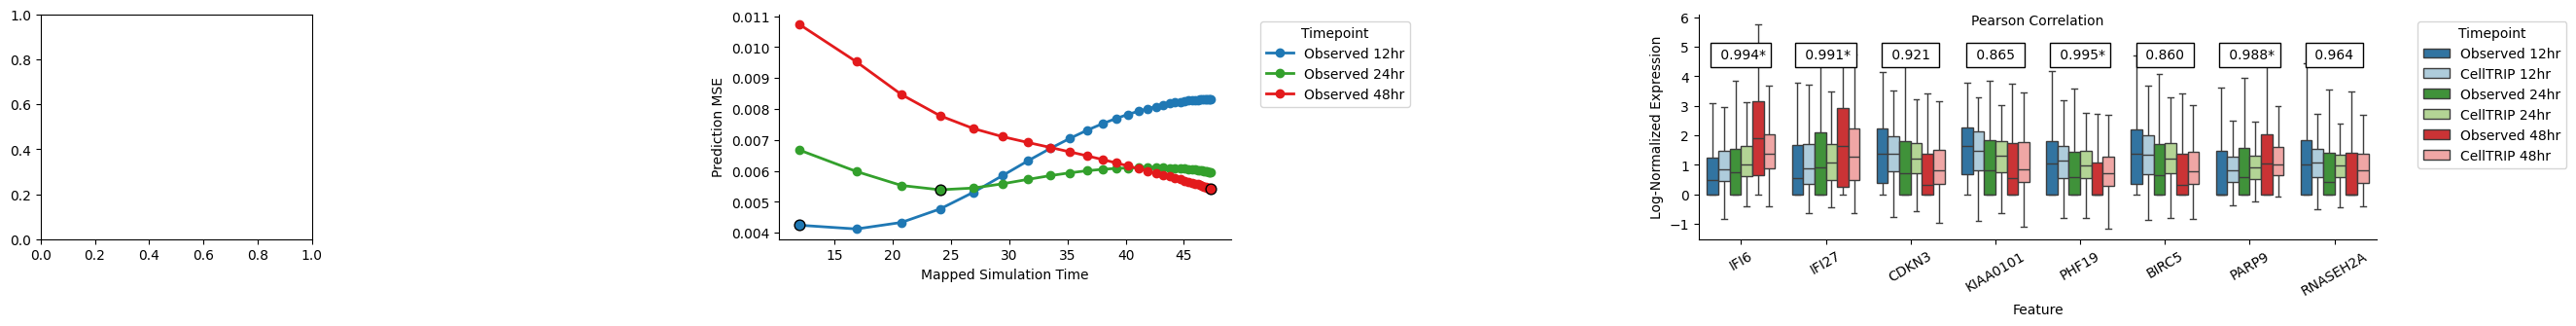

In [ ]:
# Generate figure
widths = [6, 10, 15]
fig, axs = plt.subplots(1, 3, figsize=(sum(widths), 3), width_ratios=widths)
fig.subplots_adjust(wspace=1.)
# Result tuples
point_tuples = [
    ('Observed 12hr', start_exp),
    ('Observed 24hr', interp_exp),
    ('Observed 48hr', end_exp)]
    # ('Observed 12hr', normalize_counts(start_exp)),
    # ('Observed 24hr', normalize_counts(interp_exp)),
    # ('Observed 48hr', normalize_counts(end_exp))]
    # ('Observed 12hr', preprocessing.transform([start_exp])[0]),
    # ('Observed 24hr', preprocessing.transform([interp_exp])[0]),
    # ('Observed 48hr', preprocessing.transform([end_exp])[0])]
# celltrip_transition_idx = 6
celltrip_tuples = [
    ('CellTRIP 12hr', transition_states_exp[0]),
    ('CellTRIP 24hr', transition_states_exp[celltrip_transition_idx]),
    ('CellTRIP 48hr', transition_states_exp[-1])]
    # ('CellTRIP 12hr', preprocess_common(transition_states_exp[0])),
    # ('CellTRIP 24hr', preprocess_common(transition_states_exp[3])),
    # ('CellTRIP 48hr', preprocess_common(transition_states_exp[-1]))]
    # ('CellTRIP 12hr', preprocessing.transform([transition_states_exp[0]])[0]),
    # ('CellTRIP 24hr', preprocessing.transform([transition_states_exp[3]])[0]),
    # ('CellTRIP 48hr', preprocessing.transform([transition_states_exp[-1]])[0])]
# Combine tuples
all_tuples = point_tuples + celltrip_tuples
all_tuples = list(all_tuples[::3]) + list(all_tuples[1::3]) + list(all_tuples[2::3])
# Paired colors
all_colors = sns.color_palette('Paired', 6)
colors = list(all_colors[1::2]) + list(all_colors[::2])
all_colors = list(colors[::3]) + list(colors[1::3]) + list(colors[2::3])

# UMAP
# ax = axs[0]
# reduction = umap.UMAP(n_neighbors=200, random_state=42).fit(np.concat(list(map(lambda t: t[1], point_tuples)), axis=0))
# for (name, points), color in tqdm.tqdm(zip(all_tuples, all_colors), desc='UMAP Transform', total=len(all_tuples)):
#     ax.scatter(*reduction.transform(points).T, s=5., color=color, label=name)
# ax.set_aspect('equal')
# sns.despine(ax=ax)
# ax.set(xlabel='UMAP-1', ylabel='UMAP-2')
# ax.legend(title='Timepoint', loc='upper left', bbox_to_anchor=(1.05, 1.))

# Distance by timepoint
ax = axs[1]
for i, (name, points) in tqdm.tqdm(enumerate(point_tuples), desc='Distance by Timepoint', total=len(point_tuples)):
    # Get error
    # err = np.square(transition_states_exp - np.expand_dims(points, axis=0)).mean(axis=(-2, -1))
    # emd = np.array([celltrip.utility.distance.compute_emd(tse, points) for tse in transition_states_exp])  # EMD
    mse = np.square(transition_states_exp.mean(axis=1) - points.mean(keepdims=True, axis=0)).mean(axis=-1)  # MSE
    # err = np.array([
    #     celltrip.utility.distance.compute_emd(tse, preprocessing.transform([points])[0])
    #     for tse in preprocessing.transform([
    #         transition_states_exp.reshape([-1, transition_states_exp.shape[-1]])])[0].reshape([
    #             *transition_states_exp.shape[:2], -1])])
    err = mse
    # Plot
    ax.plot(transition_bio_time, err, color=colors[i], lw=2, marker='o', markersize=6, label=f'{name}')
    # ax.plot(transition_bio_time, mse, color=colors[i], lw=2, ls='--', markersize=6, label=f'{name} - MSE')
    if name == 'Observed 12hr':
        ax.scatter(transition_bio_time[[0]], err[[0]], color=all_colors[2*i], edgecolors='black', marker='o', s=60, zorder=2)
    elif name == 'Observed 24hr':
        if celltrip_transition_idx == 'auto':
            celltrip_transition_idx = err.argmin()
        ax.scatter(transition_bio_time[[celltrip_transition_idx]], err[[celltrip_transition_idx]], color=all_colors[2*i], edgecolors='black', marker='o', s=60, zorder=2)
    elif name == 'Observed 48hr':
        ax.scatter(transition_bio_time[[-1]], err[[-1]], color=all_colors[2*i], edgecolors='black', marker='o', s=60, zorder=2)
# Format
sns.despine(ax=ax)
ax.set(xlabel='Mapped Simulation Time', ylabel='Prediction MSE')
ax.legend(title='Timepoint', loc='upper left', bbox_to_anchor=(1.05, 1.))

# Sample gene distances
ax = axs[2]
interp_distribution = []
# Choose genes
assert preprocessing.filter_mask[0] is None
# chosen_gene_idx = np.random.choice(start_exp.shape[1], 8)  # Random
# chosen_gene_idx = preprocessing.standardize_std[0].argsort()[::-1].flatten()[:8]  # Top variant
# chosen_gene_idx = np.abs(end_exp.mean(axis=0) - start_exp.mean(axis=0)).argsort()[::-1][:8]  # Top varying by mean across stages
chosen_gene_idx = np.abs(np.median(end_exp, axis=0) - np.median(start_exp, axis=0)).argsort()[::-1][:8]  # Top varying by median across stages
chosen_genes = adata.var.loc[adata.var_names[chosen_gene_idx], 'gene_name'].tolist()
# chosen_genes = ['MAP2K1', 'MAP2K2']; chosen_gene_idx = [np.argmax(adata.var['gene_name']==gene) for gene in chosen_genes]  # Manual
for name, points in all_tuples:
    df = pd.DataFrame(points[:, chosen_gene_idx], columns=chosen_genes)
    df['Timepoint'] = name
    interp_distribution.append(df)
# Format df
interp_distribution = (
    pd.concat(interp_distribution, axis=0)
    .melt(id_vars='Timepoint', var_name='Feature', value_name='Expression'))
# Plot
box = sns.boxplot(
    interp_distribution, x='Feature', y='Expression', hue='Timepoint',
    hue_order=list(map(lambda a: a[0], all_tuples)), palette=all_colors,
    showfliers=False, ax=ax)
# Compute correlation for each gene
gene_corr = {}
for gene in chosen_genes:
    timepoint_expression = interp_distribution.loc[interp_distribution['Feature'] == gene]
    # Relies on sorting of input tuples
    # timepoint_expression = timepoint_expression.groupby('Timepoint')['Expression'].mean()  # Use means
    timepoint_expression = timepoint_expression.groupby('Timepoint')['Expression'].median()  # Use medians
    gene_corr[gene] = scipy.stats.pearsonr(
        timepoint_expression.loc[timepoint_expression.index.str.startswith('Observed')],
        timepoint_expression.loc[timepoint_expression.index.str.startswith('CellTRIP')],
        alternative='greater')
    # Oversampling
    # timepoint_expression = timepoint_expression.set_index('Timepoint')
    # timepoint_expression_observed = timepoint_expression.loc[timepoint_expression.index.str.startswith('Observed'), 'Expression']
    # timepoint_expression_celltrip = timepoint_expression.loc[timepoint_expression.index.str.startswith('CellTRIP'), 'Expression']
    # timepoint_expression_observed_idx, timepoint_expression_celltrip_idx = [], []
    # for timepoint_observed, timepoint_celltrip in zip(timepoint_expression_observed.index.unique(), timepoint_expression_celltrip.index.unique()):
    #     timepoint_expression_observed_idx.append(np.argwhere(timepoint_expression_observed.index==timepoint_observed).flatten())
    #     timepoint_expression_celltrip_idx.append(np.argwhere(timepoint_expression_celltrip.index==timepoint_celltrip).flatten())
    #     maxlen = max(timepoint_expression_observed_idx[-1].shape[0], timepoint_expression_celltrip_idx[-1].shape[0])
    #     timepoint_expression_observed_idx[-1] = timepoint_expression_observed_idx[-1][np.arange(maxlen) % timepoint_expression_observed_idx[-1].shape[0]]
    #     timepoint_expression_celltrip_idx[-1] = timepoint_expression_celltrip_idx[-1][np.arange(maxlen) % timepoint_expression_celltrip_idx[-1].shape[0]]
    # timepoint_expression_observed_idx = np.concat(timepoint_expression_observed_idx, axis=0)
    # timepoint_expression_celltrip_idx = np.concat(timepoint_expression_celltrip_idx, axis=0)
    # gene_corr[gene] = scipy.stats.pearsonr(
    #     timepoint_expression_observed.iloc[timepoint_expression_observed_idx],
    #     timepoint_expression_celltrip.iloc[timepoint_expression_celltrip_idx],
    #     alternative='greater')
# Annotate
ax.text(
    .5, 1., f'Pearson Correlation', ha='center', va='top', transform=ax.transAxes)
for i, gene in enumerate(chosen_genes):
    corr, p = gene_corr[gene].statistic, gene_corr[gene].pvalue
    corr_str = f'{gene_corr[gene].statistic: >6.3f}'
    corr_str += '*' if p < .05 else ' '
    ax.text(
        i, .85, corr_str, ha='center', va='top',
        bbox=dict(facecolor='white', edgecolor='black'),
        transform=mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes))
# Format
ax.set_ylabel('Log-Normalized Expression')
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
sns.despine(ax=ax)
sns.move_legend(box, loc='upper left', bbox_to_anchor=(1.05, 1.))
# ax.set_ylim(bottom=0)

fig.savefig('../plots/drugseries/Interpolation_Performance.pdf')


In [ ]:
# 'DrugSeries-251113-pip'